# Overview
This notebook just takes the JSON files for 2020, 2021, 2022, 2023, 2024 and 2025 of energy charts and merges them together into one single dataset and saves it as a CSV for later use

In [1]:
# Import libraries
import pandas as pd
import json
import os
from collections import defaultdict
import math

In [2]:
# Import all the JSON files

df_2025 = pd.read_json('data_2025.json')
df_2024 = pd.read_json('data_2024.json')
df_2023 = pd.read_json('data_2023.json')
df_2022 = pd.read_json('data_2022.json')
df_2021 = pd.read_json('data_2021.json')
df_2020 = pd.read_json('data_2020.json')

In [3]:
# print all of the 'name' in 2025
print("-------------------------")
print("2025")
print(df_2025['name'])
# print all of the 'name' in 2024
print("-------------------------")
print("2024")
print(df_2024['name'])
# print all of the 'name' in 2023
print("-------------------------")
print("2023")
print(df_2023['name'])
# print all of the 'name' in 2022
print("-------------------------")
print("2022")
print(df_2022['name'])
# print all of the 'name' in 2021
print("-------------------------")
print("2021")
print(df_2021['name'])
# print all of the 'name' in 2020
print("-------------------------")
print("2020")
print(df_2020['name'])


-------------------------
2025
0     {'en': 'Hydro pumped storage consumption', 'de...
1     {'en': 'Cross border electricity trading', 'de...
2     {'en': 'Non-Renewable', 'de': 'Nicht Erneuerba...
3     {'en': 'Renewable', 'de': 'Erneuerbar', 'fr': ...
4     {'en': 'Load', 'de': 'Last', 'fr': 'Charge', '...
5     {'en': 'Load forecast', 'de': 'Last Prognose',...
6     [{'en': 'Day Ahead Auction (DE-LU)', 'de': 'Da...
7     [{'en': 'Day Ahead Auction EXAA (DE-LU)', 'de'...
8     [{'en': 'Intraday Continuous 15 minutes Averag...
9     [{'en': 'Pan-European Intraday auction, 15 min...
10    [{'en': 'Pan-European Intraday auction, 15 min...
11    [{'en': 'Pan-European Intraday auction, 15 min...
12    [{'en': 'Intraday Continuous 15 minutes Low Pr...
13    [{'en': 'Intraday Continuous 15 minutes High P...
14    [{'en': 'Intraday Continuous 15 minutes ID3-Pr...
15    [{'en': 'Intraday Continuous 15 minutes ID1-Pr...
16    [{'en': 'Intraday Balancing Energy Price (ID A...
17    {'en': 'CO2

In [4]:
# Combine all yearly dataframes into a single wide table keyed by Unix timestamp

source_dfs = [df_2020, df_2021, df_2022, df_2023, df_2024, df_2025]
series_map = {}
axis_registry = defaultdict(list)  # length -> list of cached axis tuples


def _normalise_name(name_value, fallback_index):
    if isinstance(name_value, dict):
        return name_value.get("en") or next(
            (v for v in name_value.values() if isinstance(v, str)),
            f"series_{fallback_index}",
        )
    if isinstance(name_value, list):
        first_dict = next((entry for entry in name_value if isinstance(entry, dict)), None)
        if first_dict:
            return first_dict.get("en") or next(
                (v for v in first_dict.values() if isinstance(v, str)),
                f"series_{fallback_index}",
            )
        return str(name_value)
    if name_value is None:
        return f"series_{fallback_index}"
    return str(name_value)


def _normalise_axis_values(x_values):
    cleaned = []
    for v in x_values:
        if isinstance(v, float):
            cleaned.append(int(v) if not math.isnan(v) else v)
        else:
            cleaned.append(v)
    return tuple(cleaned)


def _register_axis(axis_tuple):
    bucket = axis_registry[len(axis_tuple)]
    if axis_tuple not in bucket:
        bucket.append(axis_tuple)


for df in source_dfs:
    local_axis_cache = {}
    for _, row in df.iterrows():
        raw_values = row.get("data")
        if not isinstance(raw_values, (list, tuple)) or not raw_values:
            continue

        # Normalise "data" into parallel lists of x/y values
        if isinstance(raw_values[0], (list, tuple)) and len(raw_values[0]) >= 2:
            # Structure already contains timestamps alongside values
            x_values = [pair[0] for pair in raw_values]
            y_values = [pair[1] for pair in raw_values]
        else:
            y_values = list(raw_values)
            x_values = row.get("xAxisValues")

        axis_tuple = None
        if isinstance(x_values, (list, tuple)) and len(x_values) == len(y_values):
            axis_tuple = _normalise_axis_values(x_values)
        else:
            axis_tuple = local_axis_cache.get(len(y_values))
            if axis_tuple is None:
                candidates = axis_registry.get(len(y_values), [])
                axis_tuple = candidates[-1] if candidates else None

        if axis_tuple is None:
            # No matching axis available; skip until one is found
            continue

        local_axis_cache[len(axis_tuple)] = axis_tuple
        _register_axis(axis_tuple)
        x_values = list(axis_tuple)

        try:
            numeric_array = pd.to_numeric(y_values, errors="coerce")
        except Exception:
            continue

        if pd.isna(numeric_array).all():
            continue

        values = pd.Series(numeric_array, index=pd.Index(x_values, name="timestamp"), dtype="float64")

        series_name = _normalise_name(row.get("name"), len(series_map))

        existing_series = series_map.get(series_name)
        if existing_series is None:
            series_map[series_name] = values
        else:
            combined = existing_series.combine_first(values)
            series_map[series_name] = combined

if not series_map:
    raise ValueError("No valid time series found in the provided JSON dataframes")

ordered_items = list(series_map.items())
wide_df = pd.concat([item[1] for item in ordered_items], axis=1)
wide_df.columns = [item[0] for item in ordered_items]
wide_df = wide_df.sort_index()
wide_df.index = wide_df.index.astype("int64")

In [5]:
wide_df.columns

Index(['Hydro pumped storage consumption', 'Cross border electricity trading',
       'Nuclear', 'Non-Renewable', 'Renewable', 'Load',
       'Day Ahead Auction EXAA (DE-LU)',
       'Intraday Continuous 15 minutes Average Price (DE-LU)',
       'Intraday auction 15 minutes call (DE-LU)',
       'Intraday Continuous 15 minutes Low Price (DE-LU)',
       'Intraday Continuous 15 minutes High Price (DE-LU)',
       'Intraday Continuous 15 minutes ID3-Price (DE-LU)',
       'Intraday Continuous 15 minutes ID1-Price (DE-LU)',
       'Intraday Balancing Energy Price (ID AEP) 15 minutes (DE-LU)',
       'CO2 Emission Allowances, Auction DE',
       'CO2 Emission Allowances, Auction EU',
       'Pan-European Intraday auction, 15 minutes IDA1 price (DE-LU)',
       'Pan-European Intraday auction, 15 minutes IDA2 price (DE-LU)',
       'Pan-European Intraday auction, 15 minutes IDA3 price (DE-LU)',
       'Load forecast', 'Day Ahead Auction (DE-LU)'],
      dtype='object')

In [6]:
# Select the columns required for the final export
_day_ahead_col = "Day Ahead Auction EXAA (DE-LU)"
_day_ahead_alt_col = "Day Ahead Auction (DE-LU)"
_intraday_avg_col = "Intraday Continuous 15 minutes Average Price (DE-LU)"
_base_columns = [
    "Nuclear",
    "Non-Renewable",
    "Renewable",
    "Load",
]
_missing_columns = [
    col
    for col in _base_columns + [_day_ahead_col, _day_ahead_alt_col, _intraday_avg_col]
    if col not in wide_df.columns
]
if _missing_columns:
    raise KeyError(f"Missing expected columns: {_missing_columns}")

_day_ahead_combined_col = "Day Ahead Auction (combined)"
wide_df[_day_ahead_combined_col] = wide_df[_day_ahead_col].combine_first(
    wide_df[_day_ahead_alt_col]
)

_columns_to_keep = _base_columns + [_day_ahead_combined_col, _intraday_avg_col]

wide_df = (
    wide_df
    .loc[:, _columns_to_keep]
    .reset_index()
    .rename(columns={"timestamp": "Timestamp"})
)
wide_df = wide_df[["Timestamp"] + _columns_to_keep]


In [7]:
# Rename columns for clarity
wide_df.rename(
    columns={
        "Day Ahead Auction (combined)": "Day Ahead Auction",
        "Intraday Continuous 15 minutes Average Price (DE-LU)": "Spot Price",
    },
    inplace=True,
)

# set the index to the timestamp column
wide_df.set_index("Timestamp", inplace=True)



In [8]:
# convert timestamp from UNIX to datetime
wide_df.index = pd.to_datetime(wide_df.index, unit="ms")

wide_df.columns

Index(['Nuclear', 'Non-Renewable', 'Renewable', 'Load', 'Day Ahead Auction',
       'Spot Price'],
      dtype='object')

In [9]:
# Try to only keep the only every 4th row
wide_df_hourly = wide_df.iloc[::4]

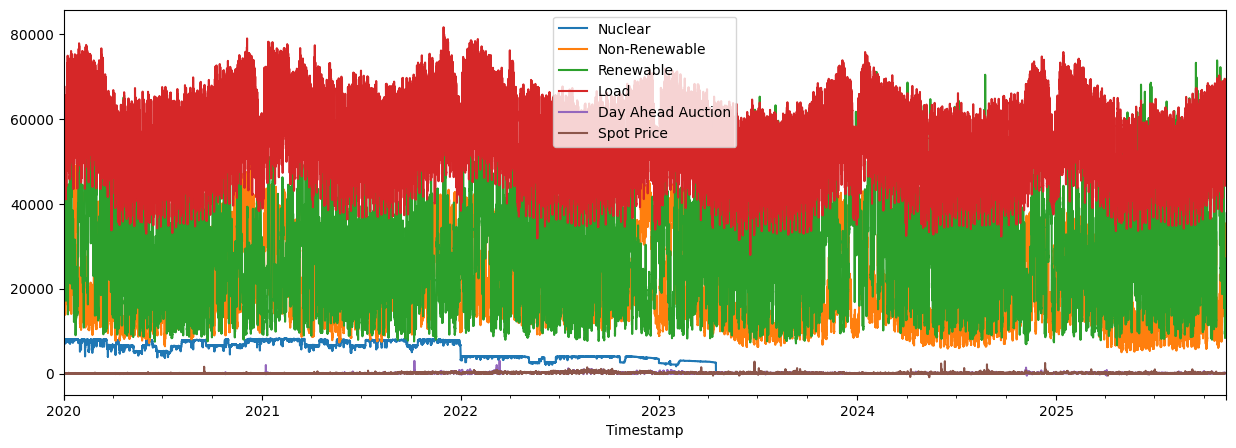

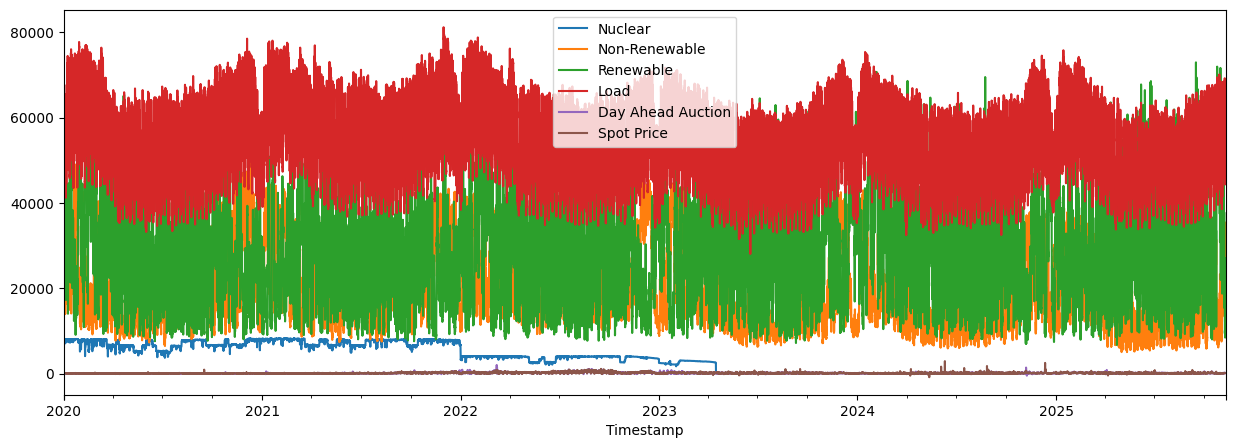

In [12]:
# Plot the day ahead auction and spot price of the wide dataframe for the last 20000 rows
import matplotlib.pyplot as plt

ax = wide_df.plot(figsize=(15, 5))
plt.show()

# Plot the day ahead auction and spot price of the wide dataframe for the last 2000 rows (hourly)
ax2 = wide_df_hourly.plot(figsize=(15, 5))
plt.show()

In [16]:
# Optionally save the merged dataset
wide_df_hourly.to_csv("energy_data.csv", index=True)
